<a href="https://colab.research.google.com/github/cwleonard1w45/SentimentalAnalysis/blob/main/SentimentalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

In [4]:
url ="https://raw.githubusercontent.com/cwleonard1w45/SentimentalAnalysis/refs/heads/main/IMDB%20Dataset.csv"
data= pd.read_csv(url)



In [5]:
data['sentiment'].value_counts()

,count
sentiment,
negative,263
positive,237


In [6]:
data.dropna(inplace=True)

In [7]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
495,"""American Nightmare"" is officially tied, in my...",negative
496,"First off, I have to say that I loved the book...",negative
497,This movie was extremely boring. I only laughe...,negative
498,I was disgusted by this movie. No it wasn't be...,negative


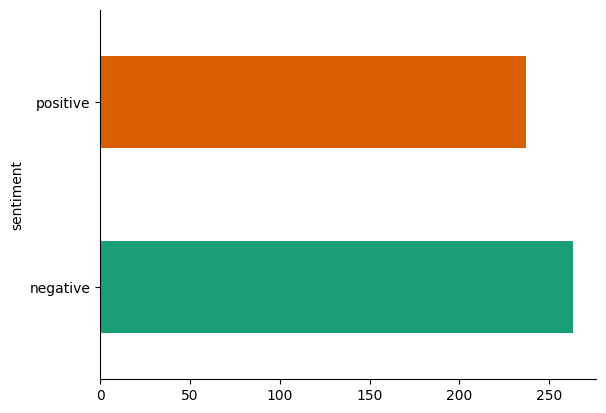

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [9]:
def clean_review(review):
    str=' '.join(word for word in review.split() if word.lower() not in stopwords.words('english'))
    return str

In [10]:
!pip install nltk
import nltk
nltk.download('stopwords')

def clean_review(review):
    str=' '.join(word for word in review.split() if word.lower() not in stopwords.words('english'))
    return str

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
data['review'] = data['review'].apply(clean_review)

In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:

from wordcloud import WordCloud

Visualizing the words which repeats themself in reviews and displaying them in order of their size.

Number of negative reviews: 263
Reviews string: Basically there's family little boy (Jake) thinks there's zombie closet & parents fighting time.This...


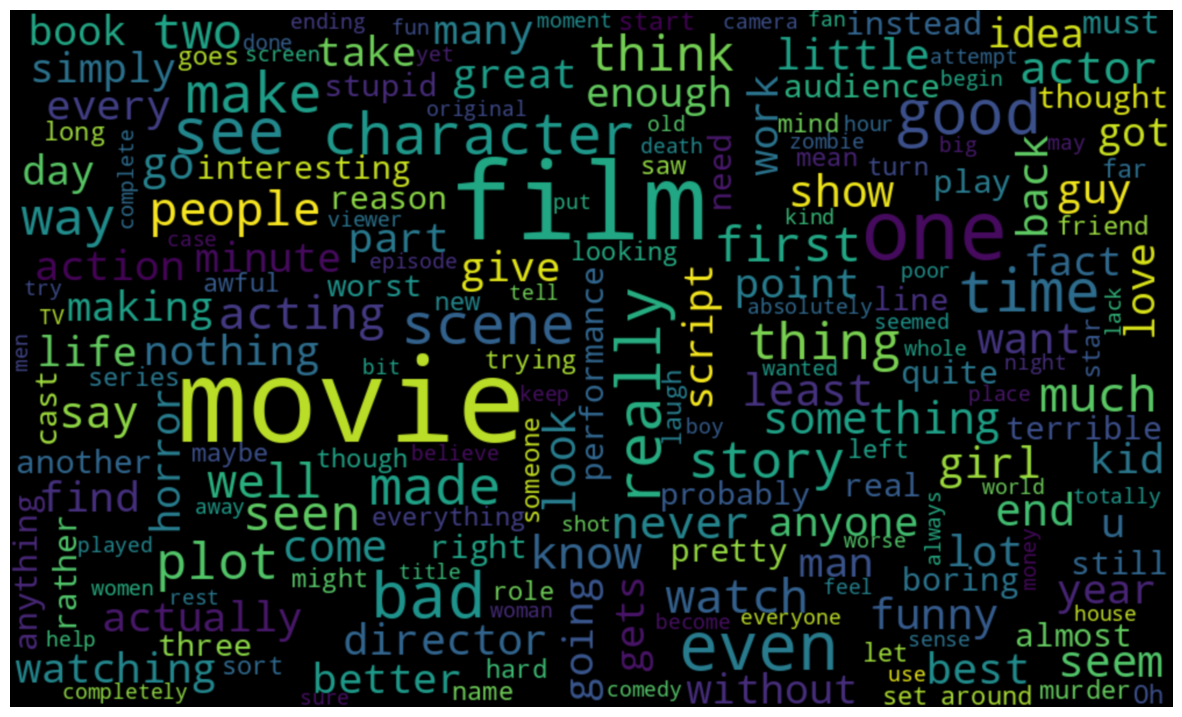

In [14]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt


negative_reviews = data['review'][data['sentiment'] == 'negative'].astype(str)
print(f"Number of negative reviews: {len(negative_reviews)}")


if len(negative_reviews) > 0:
    reviews = ' '.join(word for word in negative_reviews)
    print(f"Reviews string: {reviews[:100]}...")

    wordcloud = WordCloud(height = 600,width = 1000, max_font_size = 100)
    plt.figure(figsize = (15,12))
    plt.imshow(wordcloud.generate(reviews),interpolation='bicubic')
    plt.axis('off')
    plt.show()
else:
    print("No negative reviews found.")

Number of positive reviews: 237
Reviews string: One reviewers mentioned watching 1 Oz episode hooked. right, exactly happened me.The first thing str...


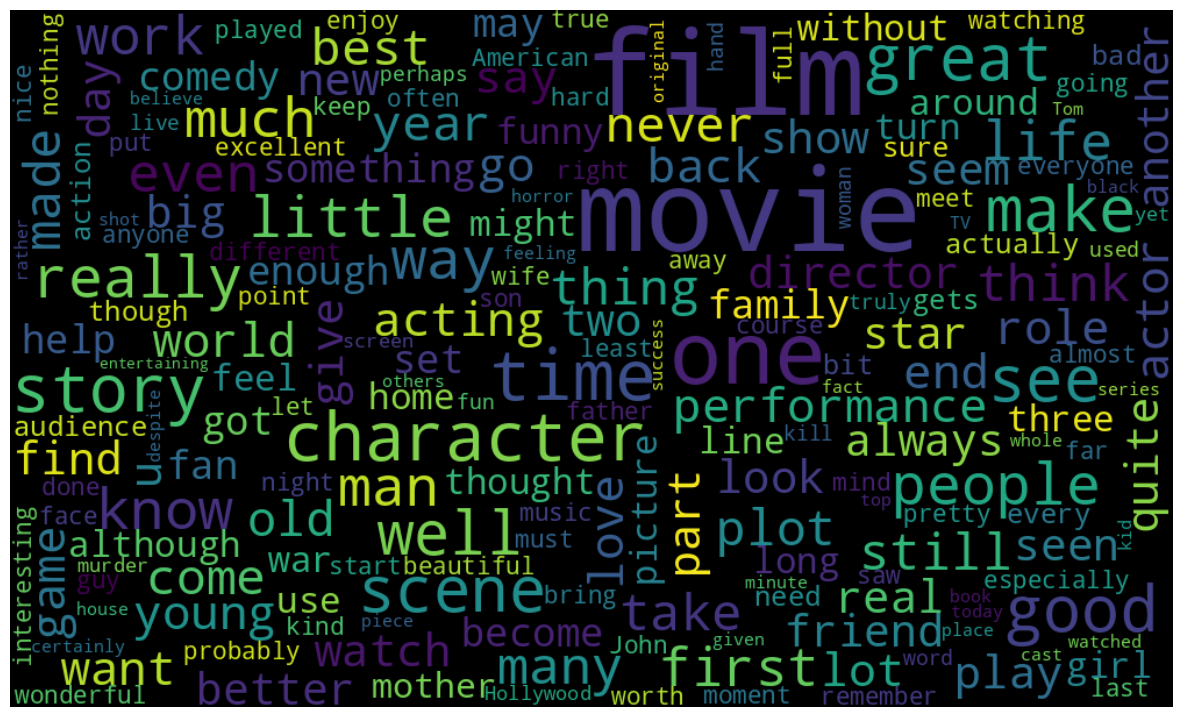

In [15]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_reviews = data['review'][data['sentiment'] == 'positive'].astype(str)
print(f"Number of positive reviews: {len(positive_reviews)}")


if len(positive_reviews) > 0:
    reviews = ' '.join(word for word in positive_reviews)
    print(f"Reviews string: {reviews[:100]}...")

    wordcloud = WordCloud(height = 600,width = 1000, max_font_size = 100)
    plt.figure(figsize = (15,12))
    plt.imshow(wordcloud.generate(reviews),interpolation='bilinear')
    plt.axis('off')
    plt.show()
else:
    print("No positive reviews found.")

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(max_features=2500)

In [17]:
reviews = cv.fit_transform(data['review']).toarray()

Supervising the dataset.


In [18]:
data['sentiment'] = data['sentiment'].replace(['positive','negative'],[1,0])

/tmp/ipython-input-3911524901.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['sentiment'] = data['sentiment'].replace(['positive','negative'],[1,0])


In [19]:
data['sentiment'].value_counts()

,count
sentiment,
0,263
1,237


# data is **ready**

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression()

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
review_train, review_test, sent_train, sent_test = train_test_split(reviews, data['sentiment'], test_size=0.2)

In [24]:
model.fit(review_train, sent_train)

LogisticRegression()

In [25]:
predict = model.predict(review_test)

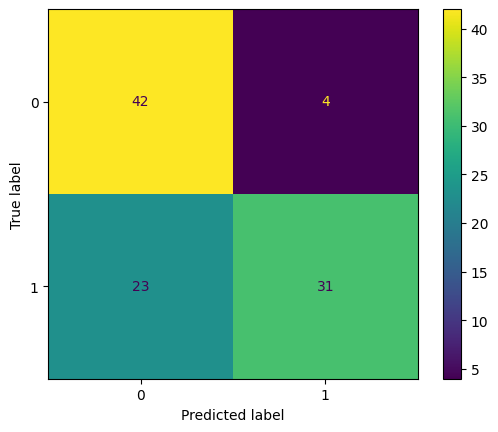

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


predict = model.predict(review_test)

cm = confusion_matrix(sent_test, predict, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [27]:
import pickle as pk

In [28]:
pk.dump(model, open('model.pkl', 'wb'))

In [32]:
#Note : Try a few times after full code is executed.
review_input = "i did not liked the action" #@param {type:"string"}
rating = 2 #@param {type:"slider", min:1, max:5, step:1}

import pickle as pk
model = pk.load(open('model.pkl', 'rb'))

def predict_sentiment(review):
  review = clean_review(review)
  review_vector = cv.transform([review]).toarray()
  prediction = model.predict(review_vector)[0]
  return "Positive" if prediction == 1 else "Negative"

if review_input:
  sentiment = predict_sentiment(review_input)
  print(f"Sentiment: {sentiment}")
else:
  print("Please enter a review.")

Sentiment: Negative
